In [10]:
pip install torch_geometric

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import torch
from torch_geometric.datasets import FB15k_237

dataset = FB15k_237(root='Data/fb15k')
data = dataset[0]

print(f"Nodes:     {data.num_nodes}")
print(f"Relations: {int(data.edge_type.max().item()) + 1}")
print(f"Edges:     {data.edge_index.shape[1]}")
print(data)

Nodes:     14541
Relations: 237
Edges:     272115
Data(edge_index=[2, 272115], edge_type=[272115], num_nodes=14541)


Using device: cpu
Train edges: 190480
Val edges:   40817
Test edges:  40818
Starting R-GCN training on FB15k-237...
--------------------------------------------------
Epoch   1/100 | Train Loss: 1.0102 | Val Loss: 1.0543
Epoch  10/100 | Train Loss: 0.2915 | Val Loss: 0.2868
Epoch  20/100 | Train Loss: 0.1360 | Val Loss: 0.1638
Epoch  30/100 | Train Loss: 0.0869 | Val Loss: 0.1168
Epoch  40/100 | Train Loss: 0.0638 | Val Loss: 0.0941
Epoch  50/100 | Train Loss: 0.0531 | Val Loss: 0.0851
Epoch  60/100 | Train Loss: 0.0459 | Val Loss: 0.0790
Epoch  70/100 | Train Loss: 0.0422 | Val Loss: 0.0767
Epoch  80/100 | Train Loss: 0.0388 | Val Loss: 0.0714
Epoch  90/100 | Train Loss: 0.0363 | Val Loss: 0.0716
Epoch 100/100 | Train Loss: 0.0349 | Val Loss: 0.0712

Training complete.


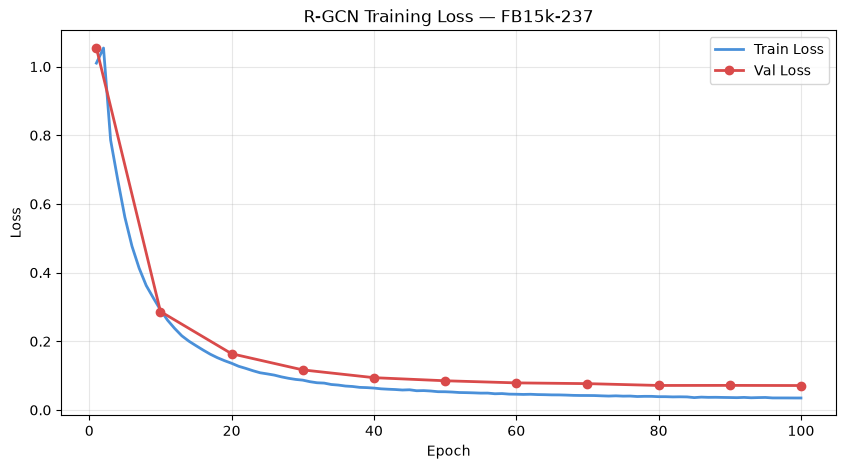

Loss curve saved.


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import RGCNConv
from torch_geometric.datasets import FB15k_237
import matplotlib.pyplot as plt

# ── Device ────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── Load dataset ──────────────────────────────────────────────
dataset = FB15k_237(root='data/fb15k')
data    = dataset[0]

num_nodes     = data.num_nodes        # 14541
num_relations = int(data.edge_type.max().item()) + 1 # 237
EMBEDDING_DIM = 100
EPOCHS        = 100
LR            = 0.01
NEG_PER_EDGE  = 1  # negatives sampled per positive triple, bump if you want harder training

edge_index = data.edge_index.to(device)  # [2, 272115]
edge_type  = data.edge_type.to(device)   # [272115]

# Split edges 70/15/15
num_edges = edge_index.shape[1]
torch.manual_seed(42)
perm      = torch.randperm(num_edges)

train_end = int(0.7 * num_edges)
val_end   = int(0.85 * num_edges)

train_idx = perm[:train_end]
val_idx   = perm[train_end:val_end]
test_idx  = perm[val_end:]

train_edge_index = edge_index[:, train_idx]
train_edge_type  = edge_type[train_idx]
val_edge_index   = edge_index[:, val_idx]
val_edge_type    = edge_type[val_idx]
test_edge_index  = edge_index[:, test_idx]
test_edge_type   = edge_type[test_idx]

print(f"Train edges: {train_edge_index.shape[1]}")
print(f"Val edges:   {val_edge_index.shape[1]}")
print(f"Test edges:  {test_edge_index.shape[1]}")

# ── R-GCN Model ───────────────────────────────────────────────
class RGCN(nn.Module):
    def __init__(self, num_nodes, num_relations, embedding_dim):
        super(RGCN, self).__init__()
        self.entity_embeddings = nn.Embedding(num_nodes, embedding_dim)
        self.conv1 = RGCNConv(embedding_dim, embedding_dim, num_relations)
        self.conv2 = RGCNConv(embedding_dim, embedding_dim, num_relations)
        self.relation_embeddings = nn.Embedding(num_relations, embedding_dim)

        nn.init.xavier_uniform_(self.entity_embeddings.weight)
        nn.init.xavier_uniform_(self.relation_embeddings.weight)

    def encode(self, edge_index, edge_type):
        # NOTE: this runs message passing over the WHOLE graph.
        # Call it once per epoch (or once per forward pass), never per mini-batch.
        x = self.entity_embeddings.weight
        x = F.relu(self.conv1(x, edge_index, edge_type))
        x = self.conv2(x, edge_index, edge_type)
        return x

    def score(self, h_emb, r_emb, t_emb):
        return -torch.norm(h_emb + r_emb - t_emb, p=2, dim=1)


# ── Negative Sampling ─────────────────────────────────────────
def negative_sample(h, r, t, num_nodes, device):
    neg_h = h.clone()
    neg_t = t.clone()
    corrupt_tail = torch.rand(len(h), device=device) > 0.5

    neg_t[corrupt_tail]  = torch.randint(0, num_nodes, (int(corrupt_tail.sum().item()),), device=device)
    neg_h[~corrupt_tail] = torch.randint(0, num_nodes, (int((~corrupt_tail).sum().item()),), device=device)

    return neg_h, r.clone(), neg_t


# ── Training (full-batch: one encode() + one backward() per epoch) ─────
model     = RGCN(num_nodes, num_relations, EMBEDDING_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

loss_history = []
val_loss_history = []

print("Starting R-GCN training on FB15k-237...")
print("-" * 50)

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()

    # One full-graph message-passing pass per epoch
    entity_embs = model.encode(train_edge_index, train_edge_type)
    r_embs      = model.relation_embeddings.weight

    pos_h, pos_t = train_edge_index[0], train_edge_index[1]
    pos_r        = train_edge_type

    neg_h, neg_r, neg_t = negative_sample(pos_h, pos_r, pos_t, num_nodes, device)

    pos_score = model.score(entity_embs[pos_h], r_embs[pos_r], entity_embs[pos_t])
    neg_score = model.score(entity_embs[neg_h], r_embs[neg_r], entity_embs[neg_t])

    loss = torch.mean(torch.relu(1.0 - pos_score + neg_score))
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 10 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            val_entity_embs = model.encode(train_edge_index, train_edge_type)
            vh, vt = val_edge_index[0], val_edge_index[1]
            vr     = val_edge_type
            vneg_h, vneg_r, vneg_t = negative_sample(vh, vr, vt, num_nodes, device)

            vpos_score = model.score(val_entity_embs[vh], r_embs[vr], val_entity_embs[vt])
            vneg_score = model.score(val_entity_embs[vneg_h], r_embs[vneg_r], val_entity_embs[vneg_t])
            val_loss = torch.mean(torch.relu(1.0 - vpos_score + vneg_score)).item()
            val_loss_history.append((epoch, val_loss))

        print(f"Epoch {epoch:3d}/{EPOCHS} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss:.4f}")

print("\nTraining complete.")

# ── Plot ──────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), loss_history, color='#4A90D9', linewidth=2, label='Train Loss')
if val_loss_history:
    ve, vl = zip(*val_loss_history)
    plt.plot(ve, vl, color='#D94A4A', linewidth=2, marker='o', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('R-GCN Training Loss — FB15k-237')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('rgcn_fb15k_loss.png', dpi=150)
plt.show()
print("Loss curve saved.")
torch.save(model.state_dict(), 'rgcn_model.pt')

In [ ]:
CHECKPOINT_PATH = 'rgcn_model.pt'
try:
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
    print(f"Loaded checkpoint from {CHECKPOINT_PATH}")
except FileNotFoundError:
    raise FileNotFoundError(
        f"No checkpoint found at {CHECKPOINT_PATH}. "
        f"You must save the model after training with: "
        f"torch.save(model.state_dict(), '{CHECKPOINT_PATH}')"
    )
 
model.eval()
 
# ── Precompute entity/relation embeddings once ──────────────────
with torch.no_grad():
    entity_embs = model.encode(train_edge_index, train_edge_type)  # [num_nodes, dim]
    r_embs      = model.relation_embeddings.weight                  # [num_relations, dim]
 
# ── Filtered ranking eval ────────────────────────────────────────
# Known true triples for filtered ranking across all splits
known_triples = {
    (int(h), int(r), int(t))
    for h, r, t in zip(
        torch.cat([train_edge_index[0], val_edge_index[0], test_edge_index[0]]).cpu().tolist(),
        torch.cat([train_edge_type, val_edge_type, test_edge_type]).cpu().tolist(),
        torch.cat([train_edge_index[1], val_edge_index[1], test_edge_index[1]]).cpu().tolist(),
    )
}
 
def filtered_rank(h, r, t, corrupt='tail'):
    """
    Rank the true entity among all num_nodes candidates, filtering out
    other known-true triples so they don't count against the model.
    """
    with torch.no_grad():
        if corrupt == 'tail':
            h_emb = entity_embs[h].unsqueeze(0)          # [1, dim]
            r_emb = r_embs[r].unsqueeze(0)                # [1, dim]
            candidate_t = entity_embs                      # [num_nodes, dim]
            scores = model.score(
                h_emb.expand(num_nodes, -1),
                r_emb.expand(num_nodes, -1),
                candidate_t
            )
        else:  # corrupt == 'head'
            t_emb = entity_embs[t].unsqueeze(0)
            r_emb = r_embs[r].unsqueeze(0)
            candidate_h = entity_embs
            scores = model.score(
                candidate_h,
                r_emb.expand(num_nodes, -1),
                t_emb.expand(num_nodes, -1)
            )
 
        true_score = scores[t if corrupt == 'tail' else h].clone()
 
        # Filter: mask out scores of OTHER known-true triples (not the current one)
        for cand in range(num_nodes):
            if corrupt == 'tail':
                if cand != t and (h, r, cand) in known_triples:
                    scores[cand] = -1e9
            else:
                if cand != h and (cand, r, t) in known_triples:
                    scores[cand] = -1e9
 
        rank = (scores > true_score).sum().item() + 1
        return rank
 
 
# NOTE: the per-triple Python loop over num_nodes inside filtered_rank is slow
# (O(num_nodes) filtering per triple, done in Python). For FB15k-237's ~14.5K
# entities and thousands of test triples this will take a while — that's normal
# for filtered eval, not a bug. If it's too slow, evaluate on a random subset
# of e.g. 500 test triples first to sanity check before running the full set.
 
EVAL_LIMIT = 500  # set to None to evaluate on the full test set
test_h = test_edge_index[0].tolist()
test_t = test_edge_index[1].tolist()
test_r = test_edge_type.tolist()
 
if EVAL_LIMIT is not None:
    test_h, test_r, test_t = test_h[:EVAL_LIMIT], test_r[:EVAL_LIMIT], test_t[:EVAL_LIMIT]
 
ranks = []
print(f"Evaluating on {len(test_h)} test triples (both head and tail corruption)...")
 
for i, (h, r, t) in enumerate(zip(test_h, test_r, test_t)):
    rank_tail = filtered_rank(h, r, t, corrupt='tail')
    rank_head = filtered_rank(h, r, t, corrupt='head')
    ranks.append(rank_tail)
    ranks.append(rank_head)
 
    if (i + 1) % 100 == 0:
        print(f"  {i + 1}/{len(test_h)} triples evaluated")
 
ranks = torch.tensor(ranks, dtype=torch.float)
 
mrr    = (1.0 / ranks).mean().item()
hits1  = (ranks <= 1).float().mean().item()
hits3  = (ranks <= 3).float().mean().item()
hits10 = (ranks <= 10).float().mean().item()
 
print("\n" + "=" * 40)
print("Filtered Evaluation Results")
print("=" * 40)
print(f"MRR:     {mrr:.4f}")
print(f"Hits@1:  {hits1:.4f}")
print(f"Hits@3:  {hits3:.4f}")
print(f"Hits@10: {hits10:.4f}")
print("=" * 40)

Loaded checkpoint from rgcn_model.pt
Evaluating on 500 test triples (both head and tail corruption)...


NameError: name 'known_triples' is not defined